In [2]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd "/content/drive/MyDrive/"

import os
os.chdir(r"C:\Z")  # Cambia el directorio de trabajo
print(os.getcwd())  # Verifica que cambió correctamente

C:\Z


Filename: TFGF/Python/spectrums/spec-0266-51630-0003.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     139   ()      
  1  COADD         1 BinTableHDU     26   3819R x 8C   [E, E, E, J, J, E, E, E]   
  2  SPECOBJ       1 BinTableHDU    262   1R x 126C   [6A, 4A, 16A, 23A, 16A, 8A, E, E, E, J, E, E, J, B, B, B, B, B, B, J, 22A, 19A, 19A, 22A, 19A, I, 3A, 3A, 1A, J, D, D, D, E, E, 19A, 8A, J, J, J, J, K, K, J, J, J, J, J, J, K, K, K, K, I, J, J, J, J, 5J, D, D, 6A, 21A, E, E, E, J, E, 24A, 10J, J, 10E, E, E, E, E, E, E, J, E, E, E, J, E, 5E, E, 10E, 10E, 10E, 5E, 5E, 5E, 5E, 5E, J, J, E, E, E, E, E, E, 25A, 21A, 10A, E, E, E, E, E, E, E, E, J, E, E, J, 1A, 1A, E, E, J, J, 1A, 5E, 5E]   
  3  SPZLINE       1 BinTableHDU     48   29R x 19C   [J, J, J, 13A, D, E, E, E, E, E, E, E, E, E, E, J, J, E, E]   


Redshift: ['1237648720142532813']
Redshift: ['QSO']


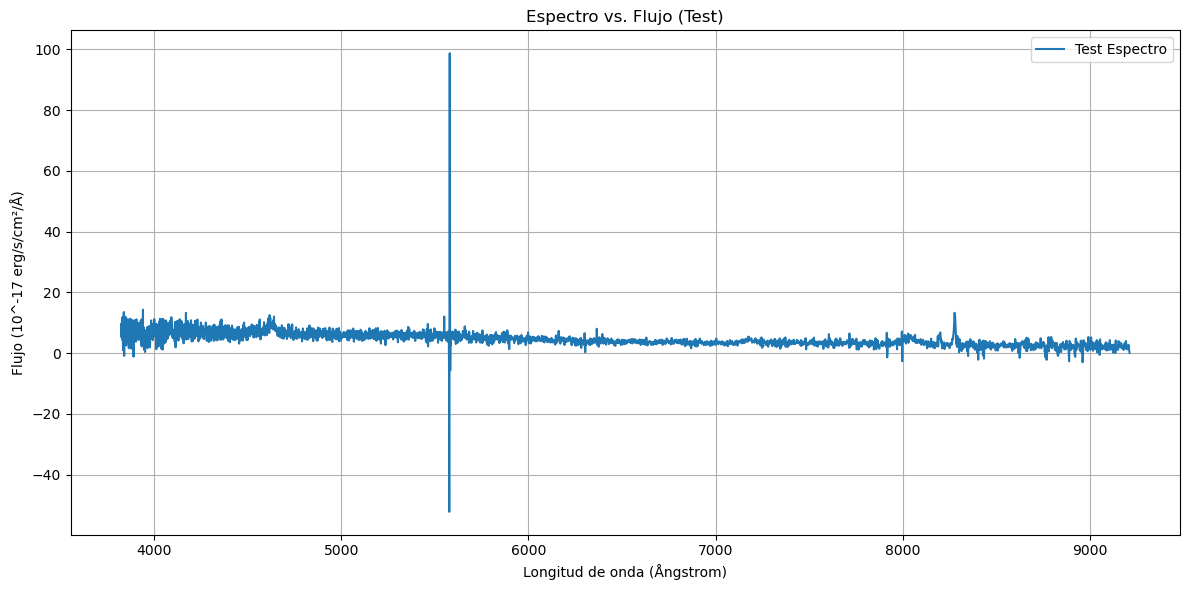

In [3]:
# TEST EXTRACCIÓN FITS

from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

# Ruta al archivo FITS
file_path = r'TFGF/Python/spectrums/spec-0266-51630-0003.fits'

# Leer el archivo FITS
with fits.open(file_path) as hdul:
    hdul.info()  # Información general del archivo

    # print(hdul[1].columns)  # Ver columnas del HDU 1
    test_flux = hdul[1].data["flux"]
    test_loglam = hdul[1].data["loglam"]

    # print(hdul[2].columns)  # Ver columnas del HDU 2
    test_redshift = hdul[2].data["BESTOBJID"]
    print("Redshift:", test_redshift)
    test_class = hdul[2].data["CLASS"]
    print("Redshift:", test_class)

# Convertir loglam a longitud de onda (Ångstroms)
test_wavelength = 10 ** test_loglam

# Graficar el espectro
plt.figure(figsize=(12, 6))
plt.plot(test_wavelength, test_flux, label="Test Espectro")
plt.xlabel("Longitud de onda (Ångstrom)")
plt.ylabel("Flujo (10^-17 erg/s/cm²/Å)")
plt.title("Espectro vs. Flujo (Test)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [4]:
# Función para interpolación adaptativa (15000 FITS = 5hrs POCO VIABLE EN DATASETS GRANDES PREPARAR LOS DATOS)

def expand_points(wavelength, flux, target_count=5000):
    # Convertimos a listas para facilitar las inserciones
    wl = list(wavelength)
    fl = list(flux)
    
    # Continuamos insertando hasta alcanzar el número deseado de puntos
    while len(wl) < target_count:
        # Calcular las diferencias absolutas en flux entre puntos consecutivos
        diffs = [abs(fl[i+1] - fl[i]) for i in range(len(fl) - 1)]
        # Encontrar el índice donde la diferencia es máxima
        max_idx = np.argmax(diffs)
        # Interpolar linealmente para obtener un nuevo punto
        new_wl = (wl[max_idx] + wl[max_idx+1]) / 2
        new_fl = (fl[max_idx] + fl[max_idx+1]) / 2
        # Insertar el nuevo punto en la posición correspondiente
        wl.insert(max_idx+1, new_wl)
        fl.insert(max_idx+1, new_fl)
        
    return np.array(wl), np.array(fl)

In [5]:
def expand_points(wavelength, flux, target_count=5000):
    import numpy as np

    # Convertir a listas para facilitar las inserciones
    wl = list(wavelength)
    fl = list(flux)
    
    # Calcular las diferencias absolutas entre puntos consecutivos
    diffs = [abs(fl[i+1] - fl[i]) for i in range(len(fl)-1)]
    # Obtener los índices ordenados de mayor a menor diferencia
    sorted_indices = sorted(range(len(diffs)), key=lambda i: diffs[i], reverse=True)
    
    # Insertar nuevos puntos utilizando los índices ordenados
    while len(wl) < target_count:
        # Se recorre la lista de índices en orden descendente para evitar problemas con el reordenamiento
        for idx in sorted_indices:
            if len(wl) >= target_count:
                break
            # Calcular la interpolación lineal entre el punto idx y el siguiente
            new_wl = (wl[idx] + wl[idx+1]) / 2
            new_fl = (fl[idx] + fl[idx+1]) / 2
            # Insertar el nuevo punto en la posición correspondiente
            wl.insert(idx+1, new_wl)
            fl.insert(idx+1, new_fl)
    
    return np.array(wl), np.array(fl)

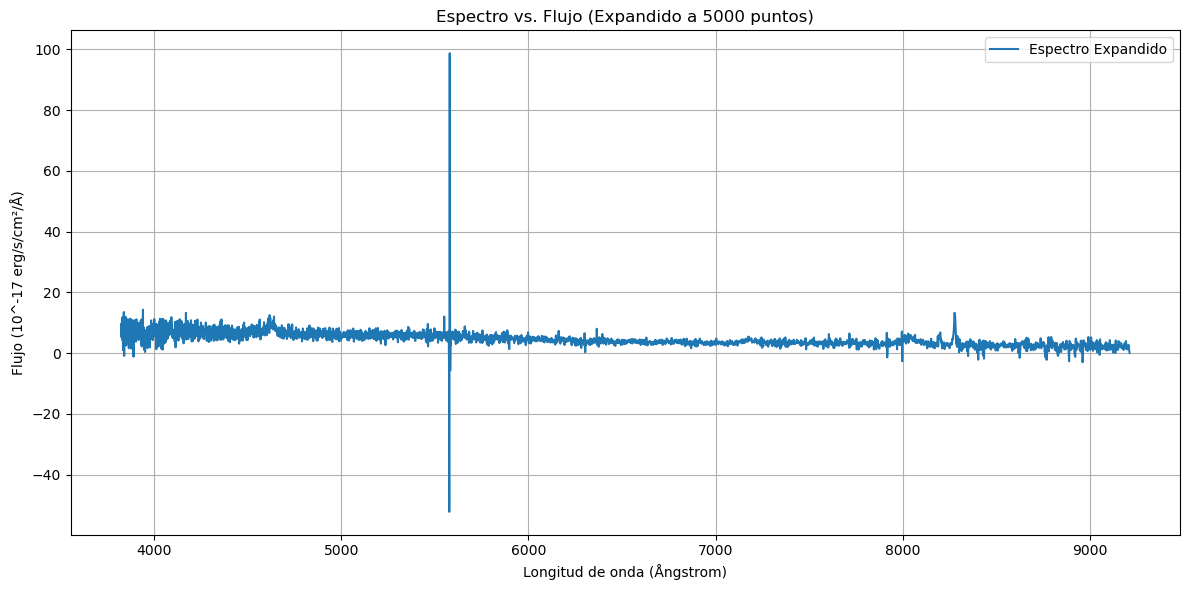

In [6]:
# TEST CON EL ANTERIOR FITS
expanded_wavelength, expanded_flux = expand_points(test_wavelength, test_flux, target_count=5000)

# Graficar el espectro ampliado
plt.figure(figsize=(12, 6))
plt.plot(expanded_wavelength, expanded_flux, label="Espectro Expandido")
plt.xlabel("Longitud de onda (Ångstrom)")
plt.ylabel("Flujo (10^-17 erg/s/cm²/Å)")
plt.title("Espectro vs. Flujo (Expandido a 5000 puntos)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
import os
from astropy.io import fits
import numpy as np
import pickle

# APLICACIÓN A LOS ARCHIVOS DE LA CARPETA SPECTRUMS
folder_path = r'TFGF NO DRIVE/Python/spectrums'

# Diccionario de almacenamiento
spectra_data = {}

# Recorrer todos los archivos .fits en la carpeta
i=0
for filename in os.listdir(folder_path):
    if filename.endswith('.fits'):
        file_path = os.path.join(folder_path, filename)
        try:
            with fits.open(file_path) as hdul:
                # Verifica que el archivo tenga las extensiones esperadas
                if len(hdul) > 2:
                    flux_data = hdul[1].data["flux"]         # Datos de flujo
                    loglam_data = hdul[1].data["loglam"]     # Datos de log(lambda)
                    wavelength_data = 10 ** loglam_data      # Convertir log(lambda) a longitud de onda
                    redshift = hdul[2].data["Z"][0]          # Extraer redshift
                    
                    # Aplicar la interpolación para obtener 5000 puntos
                    interp_wavelength, interp_flux = expand_points(wavelength_data, flux_data, target_count=5000)
                    
                    # Guardar los datos
                    spectra_data[filename] = {
                        "wavelength": interp_wavelength,
                        "flux": interp_flux,
                        "redshift": redshift
                    }

                    i=i+1
                    print(f"Procesado {filename} ({i})")
                    
        except Exception as e:
            print(f"Error procesando {filename}: {e}")

# Imprimir un resumen de los datos extraídos
print(f"Se procesaron {len(spectra_data)} archivos FITS.")

Procesado spec-1246-54478-0481.fits (1)
Procesado spec-1246-54478-0485.fits (2)
Procesado spec-1246-54478-0487.fits (3)
Procesado spec-1246-54478-0490.fits (4)
Procesado spec-1246-54478-0492.fits (5)
Procesado spec-1246-54478-0496.fits (6)
Procesado spec-1246-54478-0497.fits (7)
Procesado spec-1246-54478-0499.fits (8)
Procesado spec-1246-54478-0500.fits (9)
Procesado spec-1246-54478-0510.fits (10)
Procesado spec-1246-54478-0513.fits (11)
Procesado spec-1246-54478-0516.fits (12)
Procesado spec-1246-54478-0527.fits (13)
Procesado spec-1246-54478-0531.fits (14)
Procesado spec-1246-54478-0538.fits (15)
Procesado spec-1246-54478-0539.fits (16)
Procesado spec-1246-54478-0540.fits (17)
Procesado spec-1246-54478-0541.fits (18)
Procesado spec-1246-54478-0555.fits (19)
Procesado spec-1246-54478-0560.fits (20)
Procesado spec-1246-54478-0569.fits (21)
Procesado spec-1246-54478-0571.fits (22)
Procesado spec-1246-54478-0572.fits (23)
Procesado spec-1246-54478-0573.fits (24)
Procesado spec-1246-54478

In [8]:
# GUARDAR LOS DATOS EN UN ARCHIVO PICKLE PARA USAR EN OTRO NOTEBOOK

output_dir = r'TFGF NO DRIVE/Python/storage'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

output_file = os.path.join(output_dir, 'spectra_data_full2.pkl')

# Guardar spectra_data en un archivo pickle para usar en otro notebook
try:
    with open(output_file, 'wb') as f:
        pickle.dump(spectra_data, f)
    print(f"Spectra data guardada exitosamente en {output_file}")
except Exception as e:
    print(f"Error al guardar spectra_data: {e}")

Spectra data guardada exitosamente en TFGF NO DRIVE/Python/storage\spectra_data_full2.pkl


In [9]:
# COMRPOBAR QUE LOS DATOS TIENEN LAS DIMENSIONES CORRECTAS

# Variable para almacenar el máximo
min_flux_length = 0
max_flux_length = 0

# Recorrer los datos de cada archivo en el diccionario spectra_data
for filename, data in spectra_data.items():
    flux_length = len(data["flux"])  # Longitud del array de flujo

    if flux_length > max_flux_length:
        max_flux_length = flux_length

    if min_flux_length > flux_length:
        min_flux_length = flux_length

# Imprimir la longitud máxima encontrada
print(f"\nLa longitud máxima de flujo encontrada es: {max_flux_length}")


La longitud máxima de flujo encontrada es: 5000
